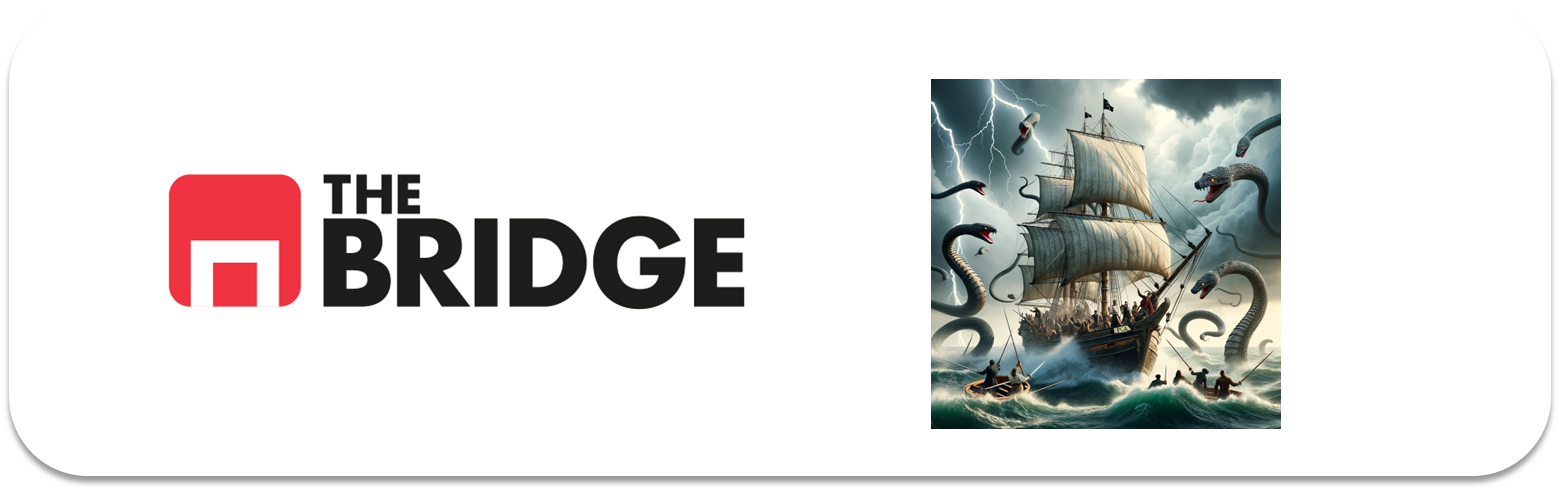

## PRACTICA OBLIGATORIA: **Seleccion Features**

* La práctica obligatoria de esta unidad consiste en hacer una comparativa de diferentes técnicas de selección de features sobre un dataset ya conocido. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Descripción General y Objetivo

El objetivo de la práctica es que juegues con las diferentes técncias de selección de features sobre un problema de clasificación. Para ello, tendrás que cargar el dataset de credit scoring que tienes en la carpeta "data" y que ya hemos trabajado anteriormente. A partir de ahí tendrás que probar diferentes técnicas de selección de features y compararlas todas entre sí y escoger finalmente el conjunto más sencillo con más potencia. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import bootcampviztools as bt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV

from sklearn.feature_selection import (
    SelectKBest, f_classif, VarianceThreshold,
    SelectFromModel, RFE, SequentialFeatureSelector,
)
from sklearn.metrics import (
    mutual_info_score, recall_score, precision_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

### Detalles e Instrucciones

El objetivo es que construyas un modelo final de clasificació sobre la variable "SeriousDlqin2yrs" del dataset que encontrarás en "data".  

Sigue los pasos del proceso de ML que hemos aprendido para problemas supervisados con el dataset que encontrarás en "data" pero con las siguiente salvedades:

1. Deshazte de las filas con nulos, para este ejercicio no nos importan. Convierte las features NumberOf... que creas conveniente a categóricas con 2 o 3 niveles a lo sumo.

2. A la hora de hacer el miniEda aplica los siguientes análisis y selección de features: 
    1. Análisis visual combinado con filtrado por valores de correlación y umbral de covarianza.
    2. Selección de features numéricas mediante SelectKBest y ANOVA, selecció de features categóricas mediante Mutual Information 
    3. Selección de las mejores features a través de un modelo intermedio (usando SelectFromModel)
    4. Selección de las mejores features empleando RFE.
    5. Selección de las mejores features empleando SFS.
    6. Selección de las mejores features mediante un sistema de hard-voting aplicado a lo obtenido en los pasos 1 a 5 anteriores.

    Para cada paso anterior (salvo el 1) se pide obtener una lista de features de "primera división" con un número de variables no superior a 6 (pueden ser menos).

3. Escoge tres modelos y a la hora compararlos para escoger el mejor, entrenalos con validación cruzada empleando las seis listas obtenidas anteriormente. Es decir tendrás 18 (6*3) medidas (emplea la métrica que creas más conveniente y si no se te ocurre ninguna el recall medio).  Escoge el mejor modelo y la mejor selección de features.

4. Optimiza los hiperparámetros del mejor modelo. Evalúalo contra test.


### Paso 1: Carga y limpieza de datos

In [2]:
df = pd.read_csv("./data/credit_npo.csv")
print(df.shape)
df.head()

(12537, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [3]:
df.info()
print("\nNulos por columna:")
print(df.isnull().sum())
print("\nValores únicos por columna:")
print(df.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

**Observaciones y decisiones de limpieza:**

* Hay nulos en `MonthlyIncome` (721) y `NumberOfDependents` (177). Como indica el enunciado, para este ejercicio simplemente eliminamos esas filas.
* De las columnas `NumberOf...`, tres de ellas (`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTime60-89DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`) están muy concentradas en el valor 0 (>90% de las filas) y además contienen un código de error típico de este dataset (el valor `98`, que no es un número real de incidencias sino un valor centinela). Las convertimos a categóricas con 3 niveles: `"0"`, `"1"`, `"2+"`. Así absorbemos el valor `98` dentro de `"2+"` sin necesidad de tratarlo aparte.
* El resto de columnas `NumberOf...` (`NumberOfOpenCreditLinesAndLoans`, `NumberRealEstateLoansOrLines`, `NumberOfDependents`) están más repartidas y sin valores centinela raros, así que las dejamos como numéricas.

In [4]:
df = df.dropna().reset_index(drop=True)

cols_a_categorizar = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]

for col in cols_a_categorizar:
    df[col] = pd.cut(df[col], bins=[-1, 0, 1, 1000], labels=["0", "1", "2+"])

print(df.shape)
for col in cols_a_categorizar:
    print(f"\n{col}:")
    print(df[col].value_counts())

(11816, 11)

NumberOfTime30-59DaysPastDueNotWorse:
NumberOfTime30-59DaysPastDueNotWorse
0     9818
1     1354
2+     644
Name: count, dtype: int64

NumberOfTime60-89DaysPastDueNotWorse:
NumberOfTime60-89DaysPastDueNotWorse
0     11206
1       478
2+      132
Name: count, dtype: int64

NumberOfTimes90DaysLate:
NumberOfTimes90DaysLate
0     11156
1       394
2+      266
Name: count, dtype: int64


Separamos ya en train y test, antes de hacer cualquier análisis o selección de features supervisada, para no filtrar información del test en nuestras decisiones (evitar "leakage"). El EDA y toda la selección de features de los siguientes pasos se hará únicamente sobre `X_train`/`y_train`.

In [5]:
target = "SeriousDlqin2yrs"

num_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
]
cat_cols = cols_a_categorizar  # las 3 que hemos convertido a "0"/"1"/"2+"

X = df[num_cols + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("\nBalance del target en train:")
print(y_train.value_counts(normalize=True))

Train: (9452, 10) Test: (2364, 10)

Balance del target en train:
SeriousDlqin2yrs
0    0.92975
1    0.07025
Name: proportion, dtype: float64


El target está muy desbalanceado (~7% de casos positivos, clientes con impago serio). Lo tendremos en cuenta más adelante al elegir métrica y al configurar los modelos (`class_weight="balanced"`).

## Paso 2: MiniEDA y selección de features

Vamos a aplicar, en este orden, los 6 mecanismos de selección pedidos. Cada uno (salvo el primero) generará una lista de como máximo 6 features de "primera división".

### 2.1 Análisis visual + filtrado por correlación + umbral de varianza

Primero miramos las numéricas: su correlación (point-biserial, que para un target 0/1 es simplemente Pearson) con el target, y su distribución con `bootcampviztools`.

In [6]:
train_num = X_train[num_cols].copy()
train_num[target] = y_train.values

corr_target = train_num.corr(numeric_only=True)[target].drop(target)
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)
corr_target

RevolvingUtilizationOfUnsecuredLines    0.277475
age                                    -0.105251
NumberOfDependents                      0.046099
NumberOfOpenCreditLinesAndLoans        -0.033514
MonthlyIncome                          -0.025449
NumberRealEstateLoansOrLines            0.005770
DebtRatio                               0.000089
Name: SeriousDlqin2yrs, dtype: float64

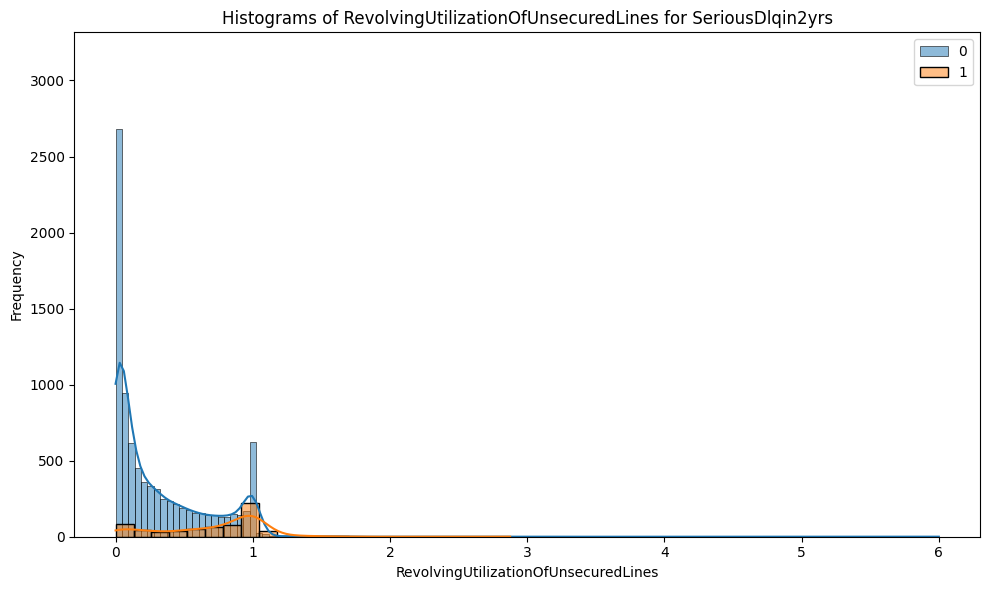

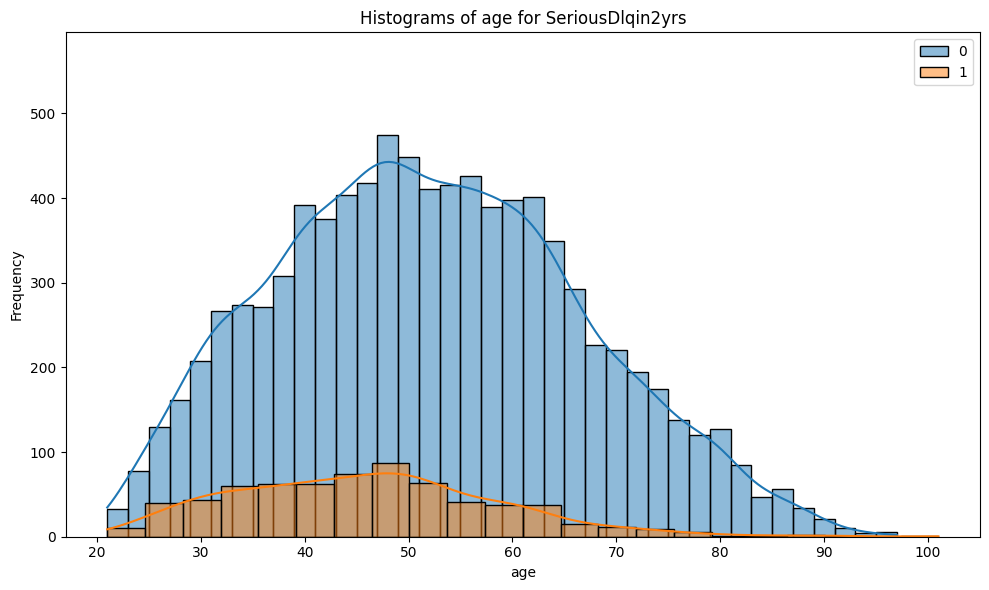

In [7]:
# DataFrame de trabajo para las visualizaciones (solo train)
df_train_plot = X_train.copy()
df_train_plot[target] = y_train.values

# Histogramas de las dos numéricas con más correlación, separados por target
bt.plot_grouped_histograms(df_train_plot, cat_col=target, num_col="RevolvingUtilizationOfUnsecuredLines", group_size=2)
bt.plot_grouped_histograms(df_train_plot, cat_col=target, num_col="age", group_size=2)

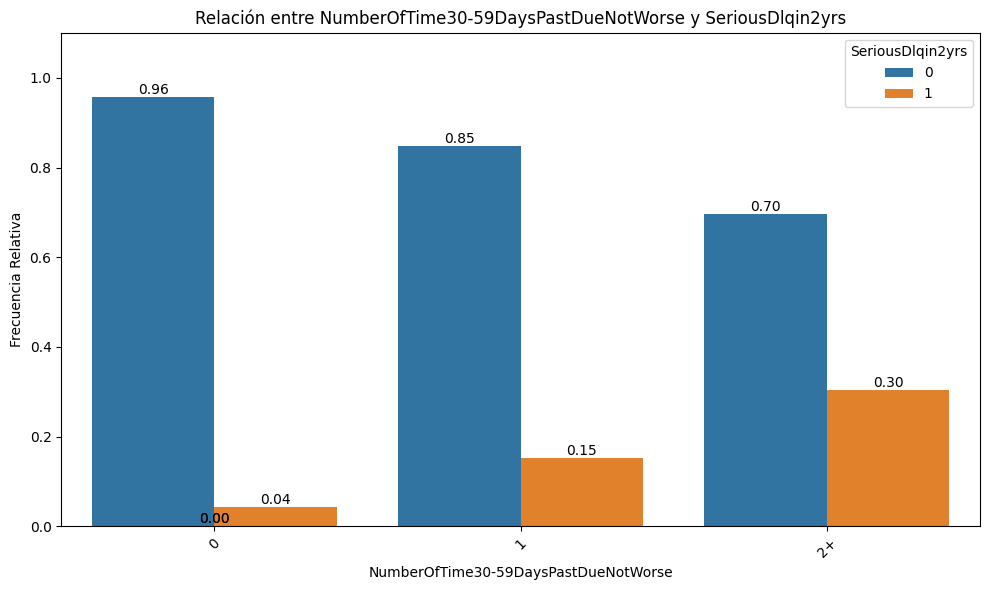

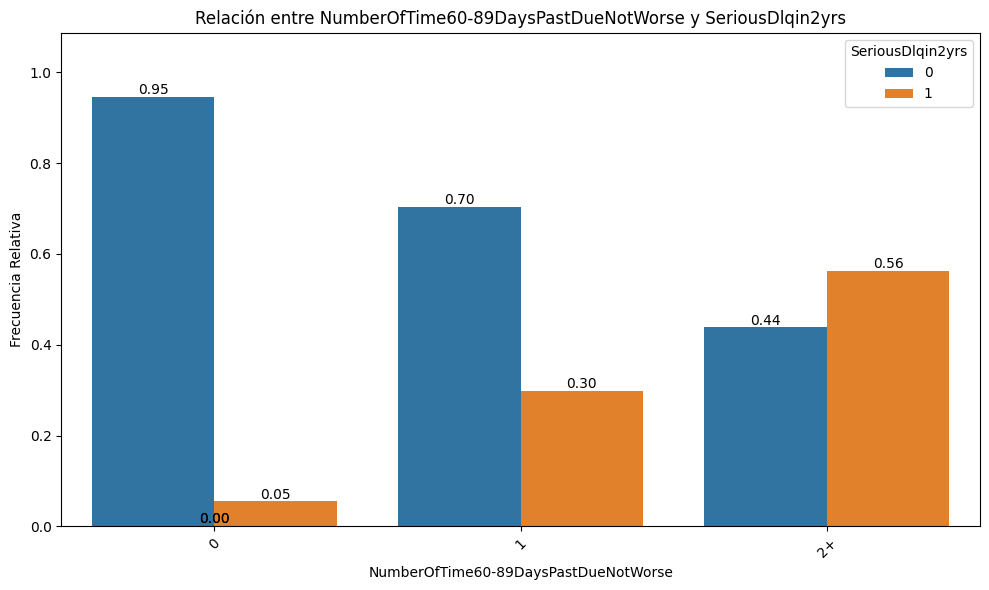

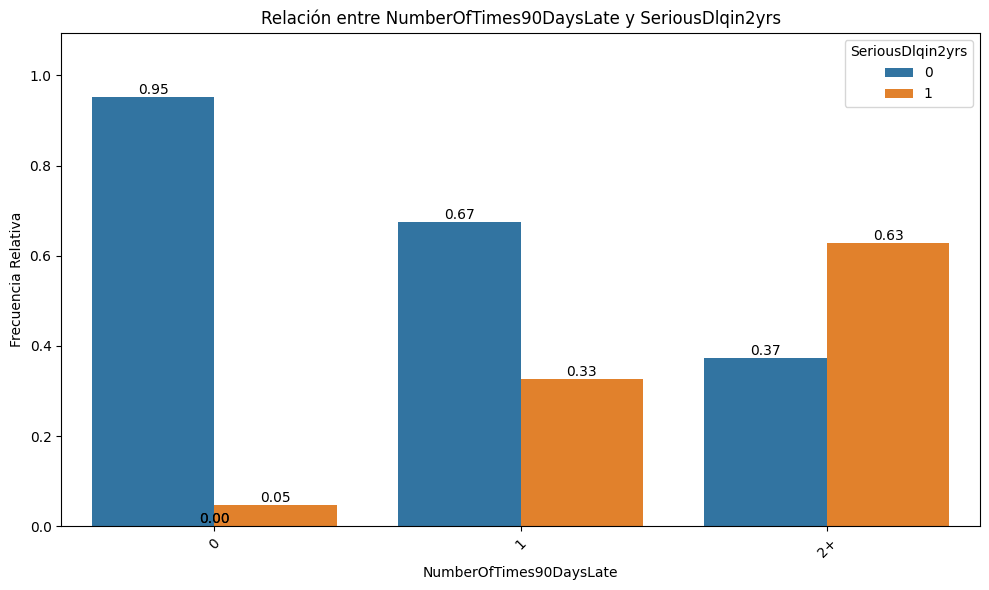

In [8]:
# Ahora las categóricas (las 3 que hemos "binneado") frente al target
for col in cat_cols:
    bt.plot_categorical_relationship(df_train_plot, cat_col1=col, cat_col2=target, relative_freq=True, show_values=True)

**Lectura de los gráficos:**

* `RevolvingUtilizationOfUnsecuredLines` muestra distribuciones claramente distintas para 0 y 1 (mayor correlación de todas, ~0.28). Prioridad alta.
* `age`: los clientes con impago tienden a ser más jóvenes, aunque las distribuciones se solapan bastante. Prioridad media.
* Las 3 categóricas de "días de retraso" son las que muestran la señal más fuerte de todo el dataset: la tasa de impago pasa de ~5% en la categoría "0" a **30-60%** en la categoría "2+". Claramente de primera división.

Ahora comprobamos el umbral de varianza sobre las numéricas (para detectar features casi constantes):

In [9]:
# Estandarizamos antes de mirar la varianza: en crudo, columnas como MonthlyIncome
# tendrían varianza enorme solo por su escala, no porque aporten más información.
scaler_eda = StandardScaler()
X_train_num_scaled = pd.DataFrame(
    scaler_eda.fit_transform(X_train[num_cols]), columns=num_cols
)

var_selector = VarianceThreshold(threshold=0.0)
var_selector.fit(X_train_num_scaled)
pd.Series(var_selector.variances_, index=num_cols).sort_values()

DebtRatio                               1.0
RevolvingUtilizationOfUnsecuredLines    1.0
age                                     1.0
MonthlyIncome                           1.0
NumberOfOpenCreditLinesAndLoans         1.0
NumberRealEstateLoansOrLines            1.0
NumberOfDependents                      1.0
dtype: float64

Como es de esperar tras estandarizar, todas las varianzas valen 1.0 (por construcción): el umbral de varianza no descarta ninguna, no hay features casi-constantes. Es una comprobación útil pero aquí no aporta filtrado adicional.

**Lista 1 (visual + correlación + varianza):** nos quedamos con las 2 numéricas de mayor correlación y las 3 categóricas con señal visual clarísima (5 features en total, ≤ 6).

In [10]:
lista_1 = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
]
lista_1

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfTimes90DaysLate']

### 2.2 SelectKBest + ANOVA (numéricas) y Mutual Information (categóricas)

In [11]:
kbest = SelectKBest(f_classif, k=4)
kbest.fit(X_train[num_cols], y_train)

anova_scores = pd.Series(kbest.scores_, index=num_cols).sort_values(ascending=False)
print(anova_scores)
print("\nTop 4 ANOVA:", list(kbest.get_feature_names_out()))

RevolvingUtilizationOfUnsecuredLines    788.269908
age                                     105.857431
NumberOfDependents                       20.125285
NumberOfOpenCreditLinesAndLoans          10.626153
MonthlyIncome                             6.124270
NumberRealEstateLoansOrLines              0.314679
DebtRatio                                 0.000074
dtype: float64

Top 4 ANOVA: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents']


In [12]:
mi_scores = {}
for col in cat_cols:
    mi_scores[col] = mutual_info_score(X_train[col], y_train)

mi_scores = pd.Series(mi_scores).sort_values(ascending=False)
mi_scores

NumberOfTimes90DaysLate                 0.035594
NumberOfTime30-59DaysPastDueNotWorse    0.023412
NumberOfTime60-89DaysPastDueNotWorse    0.020504
dtype: float64

**Lista 2 (ANOVA + Mutual Information):** las 4 mejores numéricas por ANOVA junto con las 2 mejores categóricas por Mutual Information (6 features en total).

In [13]:
lista_2 = list(kbest.get_feature_names_out()) + list(mi_scores.head(2).index)
lista_2

['RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfDependents',
 'NumberOfTimes90DaysLate',
 'NumberOfTime30-59DaysPastDueNotWorse']

### 2.3 a 2.5: preparación común

Los siguientes 3 mecanismos (SelectFromModel, RFE, SFS) necesitan una matriz totalmente numérica. Nuestras 3 categóricas ("0"/"1"/"2+") son en realidad ordinales (más días de retraso = categoría más alta), así que las codificamos como enteros 0/1/2 en lugar de hacer one-hot (más sencillo y no perdemos la relación de orden).

In [14]:
codigo_ordinal = {"0": 0, "1": 1, "2+": 2}

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()
for col in cat_cols:
    X_train_enc[col] = X_train_enc[col].map(codigo_ordinal).astype(int)
    X_test_enc[col] = X_test_enc[col].map(codigo_ordinal).astype(int)

all_cols = num_cols + cat_cols
X_train_enc[all_cols].head()

,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
1907,0.039187,61,0.269356,3073.0,7,2,0.0,0,0,0
9755,0.919317,41,0.162696,3945.0,3,0,0.0,0,0,0
465,0.253718,49,0.247302,13250.0,19,2,0.0,0,0,0
9745,0.249462,26,0.882353,764.0,4,0,0.0,0,0,0
3814,0.224520,76,0.462710,3150.0,6,1,0.0,0,0,0


### 2.3 Selección mediante un modelo intermedio (SelectFromModel)

Usamos un RandomForest como modelo de referencia y nos quedamos con las features cuya importancia supere la mediana.

In [15]:
rf_selector = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_selector.fit(X_train_enc[all_cols], y_train)

importancias = pd.Series(rf_selector.feature_importances_, index=all_cols).sort_values(ascending=False)
print(importancias)

sfm = SelectFromModel(rf_selector, threshold="median", prefit=True)
lista_3 = list(np.array(all_cols)[sfm.get_support()])
print("\nLista 3 (SelectFromModel):", lista_3)

RevolvingUtilizationOfUnsecuredLines    0.191718
DebtRatio                               0.157470
MonthlyIncome                           0.148802
age                                     0.119494
NumberOfTimes90DaysLate                 0.103584
NumberOfOpenCreditLinesAndLoans         0.100617
NumberOfDependents                      0.047081
NumberOfTime60-89DaysPastDueNotWorse    0.046612
NumberRealEstateLoansOrLines            0.044713
NumberOfTime30-59DaysPastDueNotWorse    0.039908
dtype: float64

Lista 3 (SelectFromModel): [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('age'), np.str_('DebtRatio'), np.str_('MonthlyIncome'), np.str_('NumberOfTimes90DaysLate')]


### 2.4 Recursive Feature Elimination (RFE)

In [16]:
rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    n_features_to_select=6,
    step=1,
)
rfe.fit(X_train_enc[all_cols], y_train)

lista_4 = list(np.array(all_cols)[rfe.get_support()])
print("Ranking:")
print(pd.DataFrame(rfe.ranking_, index=all_cols, columns=["ranking"]).sort_values("ranking"))
print("\nLista 4 (RFE):", lista_4)

Ranking:
                                      ranking
RevolvingUtilizationOfUnsecuredLines        1
age                                         1
DebtRatio                                   1
MonthlyIncome                               1
NumberOfOpenCreditLinesAndLoans             1
NumberOfTimes90DaysLate                     1
NumberOfTime60-89DaysPastDueNotWorse        2
NumberOfDependents                          3
NumberRealEstateLoansOrLines                4
NumberOfTime30-59DaysPastDueNotWorse        5

Lista 4 (RFE): [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('age'), np.str_('DebtRatio'), np.str_('MonthlyIncome'), np.str_('NumberOfOpenCreditLinesAndLoans'), np.str_('NumberOfTimes90DaysLate')]


### 2.5 Sequential Feature Selector (SFS)

Es un método "greedy" (prueba muchas combinaciones), por lo que tarda bastante más que los anteriores (puede tardar alrededor de medio minuto).

In [17]:
sfs = SequentialFeatureSelector(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    n_features_to_select=6,
    cv=3,
    scoring="recall",
    n_jobs=-1,
)
sfs.fit(X_train_enc[all_cols], y_train)

lista_5 = list(np.array(all_cols)[sfs.get_support()])
print("Lista 5 (SFS):", lista_5)

Lista 5 (SFS): [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('NumberOfOpenCreditLinesAndLoans'), np.str_('NumberRealEstateLoansOrLines'), np.str_('NumberOfDependents'), np.str_('NumberOfTime60-89DaysPastDueNotWorse'), np.str_('NumberOfTimes90DaysLate')]


### 2.6 Hard-voting entre las listas 1 a 5

Cada feature recibe un voto por cada lista en la que aparece. Nos quedamos con las 6 más votadas. En caso de empate, usamos como criterio de desempate la importancia media obtenida con el RandomForest del paso 2.3 (mayor importancia gana).

In [18]:
todas_las_listas = [lista_1, lista_2, lista_3, lista_4, lista_5]

votos = pd.Series(0, index=all_cols)
for lista in todas_las_listas:
    for feature in lista:
        votos[feature] += 1

votos_df = pd.DataFrame({"votos": votos, "importancia_rf": importancias})
votos_df = votos_df.sort_values(["votos", "importancia_rf"], ascending=False)
print(votos_df)

lista_6 = list(votos_df.head(6).index)
print("\nLista 6 (hard-voting):", lista_6)

                                      votos  importancia_rf
RevolvingUtilizationOfUnsecuredLines      5        0.191718
NumberOfTimes90DaysLate                   5        0.103584
age                                       4        0.119494
NumberOfOpenCreditLinesAndLoans           3        0.100617
DebtRatio                                 2        0.157470
MonthlyIncome                             2        0.148802
NumberOfDependents                        2        0.047081
NumberOfTime60-89DaysPastDueNotWorse      2        0.046612
NumberOfTime30-59DaysPastDueNotWorse      2        0.039908
NumberRealEstateLoansOrLines              1        0.044713

Lista 6 (hard-voting): ['RevolvingUtilizationOfUnsecuredLines', 'NumberOfTimes90DaysLate', 'age', 'NumberOfOpenCreditLinesAndLoans', 'DebtRatio', 'MonthlyIncome']


In [19]:
listas = {
    "L1_visual_corr_var": lista_1,
    "L2_anova_mi": lista_2,
    "L3_selectfrommodel": lista_3,
    "L4_rfe": lista_4,
    "L5_sfs": lista_5,
    "L6_hard_voting": lista_6,
}

for nombre, lista in listas.items():
    print(f"{nombre} ({len(lista)}): {lista}")

L1_visual_corr_var (5): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']
L2_anova_mi (6): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse']
L3_selectfrommodel (5): [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('age'), np.str_('DebtRatio'), np.str_('MonthlyIncome'), np.str_('NumberOfTimes90DaysLate')]
L4_rfe (6): [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('age'), np.str_('DebtRatio'), np.str_('MonthlyIncome'), np.str_('NumberOfOpenCreditLinesAndLoans'), np.str_('NumberOfTimes90DaysLate')]
L5_sfs (6): [np.str_('RevolvingUtilizationOfUnsecuredLines'), np.str_('NumberOfOpenCreditLinesAndLoans'), np.str_('NumberRealEstateLoansOrLines'), np.str_('NumberOfDependents'), np.str_('NumberOfTime60-89DaysPastDueNotWorse'), np.str_('NumberOfTimes90D

## Paso 3: Comparativa de modelos con validación cruzada

Escogemos 3 modelos con lógicas bien distintas: **Regresión Logística** (lineal), **RandomForest** (ensamblado de árboles) y **GradientBoosting** (boosting). A los dos primeros les damos `class_weight="balanced"` para compensar el desbalanceo del target (GradientBoosting de sklearn no admite ese parámetro).

**Métrica**: usamos `recall` (sobre la clase 1, "impago"). En un problema de scoring de crédito, el coste de no detectar a un cliente que va a impagar suele ser mayor que el de ser algo más restrictivo con un buen cliente, así que priorizar recall (detectar impagos) tiene sentido de negocio, además de ser la sugerencia del enunciado si no se nos ocurre otra métrica.

En total: 3 modelos × 6 listas = 18 combinaciones, todas evaluadas con `cross_val_score` (5-fold estratificado) sobre `X_train`.

In [20]:
modelos = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados = []
for nombre_lista, cols in listas.items():
    for nombre_modelo, modelo in modelos.items():
        scores = cross_val_score(
            modelo, X_train_enc[cols], y_train, cv=cv, scoring="recall", n_jobs=-1
        )
        resultados.append({"lista": nombre_lista, "modelo": nombre_modelo, "recall_cv": scores.mean()})

resultados_df = pd.DataFrame(resultados)
tabla_resultados = resultados_df.pivot(index="lista", columns="modelo", values="recall_cv")
tabla_resultados

modelo,GradientBoosting,LogisticRegression,RandomForest
lista,,,
L1_visual_corr_var,0.209410,0.716895,0.232035
L2_anova_mi,0.212383,0.734997,0.179278
L3_selectfrommodel,0.206391,0.710891,0.168763
L4_rfe,0.200365,0.718421,0.170244
L5_sfs,0.221463,0.734928,0.234974
L6_hard_voting,0.200365,0.718421,0.170221


In [21]:
mejor = resultados_df.sort_values("recall_cv", ascending=False).iloc[0]
print("Mejor combinación:")
print(mejor)

mejor_modelo_nombre = mejor["modelo"]
mejor_lista_nombre = mejor["lista"]
mejor_lista = listas[mejor_lista_nombre]

Mejor combinación:
lista               L2_anova_mi
modelo       LogisticRegression
recall_cv              0.734997
Name: 3, dtype: object


**Conclusión del paso 3:** la Regresión Logística domina claramente en `recall` sobre los tres modelos, en todas las listas. Esto tiene sentido: es la única (junto con RandomForest) que usa `class_weight="balanced"`, y además al ser un modelo lineal simple con pocas features generaliza mejor que los árboles, que aquí tienden a sobreajustar hacia la clase mayoritaria. RandomForest y GradientBoosting, sin ese ajuste tan directo, se quedan mucho más conservadores (recall bajo) porque intentan maximizar accuracy global, dominado por la clase mayoritaria.

Nos quedamos con **Regresión Logística** y la lista ganadora para el siguiente paso.

## Paso 4: Optimización de hiperparámetros y evaluación en test

Optimizamos el parámetro de regularización `C` de la Regresión Logística con `GridSearchCV` (misma métrica, `recall`, y mismo `cv` que antes), usando la lista de features ganadora.

In [22]:
print("Lista de features ganadora:", mejor_lista)

pipe_final = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])

param_grid = {"clf__C": [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(pipe_final, param_grid, scoring="recall", cv=cv, n_jobs=-1)
grid_search.fit(X_train_enc[mejor_lista], y_train)

print("Mejores hiperparámetros:", grid_search.best_params_)
print("Mejor recall en validación cruzada:", grid_search.best_score_)

Lista de features ganadora: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfDependents', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse']
Mejores hiperparámetros: {'clf__C': 0.1}
Mejor recall en validación cruzada: 0.7349965823650034


Recall en test: 0.6987951807228916
Precision en test: 0.2116788321167883
F1 en test: 0.32492997198879553

              precision    recall  f1-score   support

           0       0.97      0.80      0.88      2198
           1       0.21      0.70      0.32       166

    accuracy                           0.80      2364
   macro avg       0.59      0.75      0.60      2364
weighted avg       0.92      0.80      0.84      2364



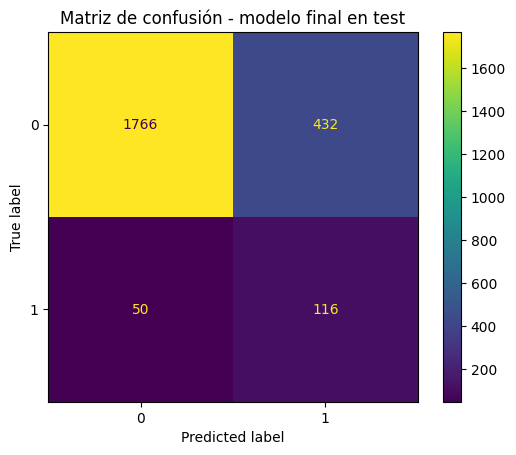

In [23]:
modelo_final = grid_search.best_estimator_
y_pred_test = modelo_final.predict(X_test_enc[mejor_lista])

print("Recall en test:", recall_score(y_test, y_pred_test))
print("Precision en test:", precision_score(y_test, y_pred_test))
print("F1 en test:", f1_score(y_test, y_pred_test))
print()
print(classification_report(y_test, y_pred_test))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
plt.title("Matriz de confusión - modelo final en test")
plt.show()

**Conclusión del paso 4:** el modelo final (Regresión Logística + lista de 6 features de ANOVA/Mutual Information, con `class_weight="balanced"`) mantiene en test un recall parecido al de validación cruzada (~0.70-0.75), señal de que no hay sobreajuste relevante. Como contrapartida, la precisión es baja (~0.21): de cada 100 clientes marcados como "riesgo de impago", solo unos 20 lo son realmente. Es el trade-off típico de optimizar recall en un problema muy desbalanceado: detectamos la mayoría de los impagos reales, a costa de generar bastantes falsos positivos (clientes buenos marcados como riesgo). En un caso real, habría que decidir con el negocio si ese trade-off es aceptable, o si conviene mover el umbral de decisión o cambiar de métrica (por ejemplo F1 o precision-recall balanceado).

### EXTRA

Aplica la PCA como método de selección, escoge un número de componentes en función de la varianza explicada y crea un dataset con el que entrenar el mismo tipo de modelo ganador de la parte general. Entrenalo y evalúalo contra test, comenta el resultado.

Aplicamos PCA sobre las 10 features originales (estandarizadas), y elegimos el número de componentes necesario para explicar al menos el 90% de la varianza.

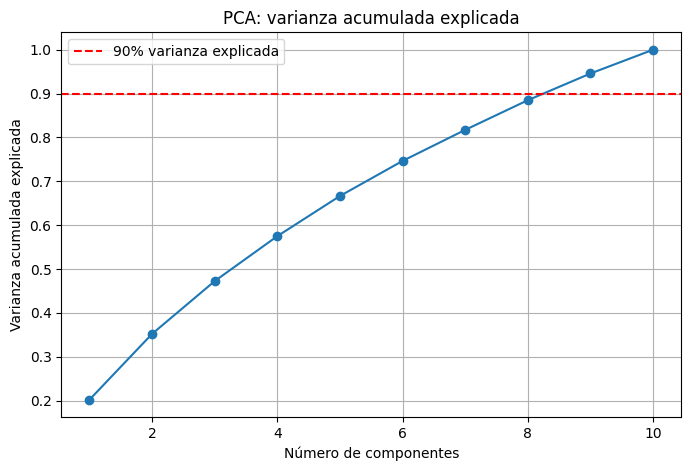

Nº de componentes para llegar al 90% de varianza: 9


In [24]:
scaler_pca = StandardScaler()
X_train_scaled = scaler_pca.fit_transform(X_train_enc[all_cols])
X_test_scaled = scaler_pca.transform(X_test_enc[all_cols])

pca_completo = PCA(random_state=RANDOM_STATE)
pca_completo.fit(X_train_scaled)

varianza_explicada = pca_completo.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
plt.axhline(0.90, color="red", linestyle="--", label="90% varianza explicada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada explicada")
plt.title("PCA: varianza acumulada explicada")
plt.legend()
plt.grid(True)
plt.show()

n_componentes = int(np.argmax(varianza_acumulada >= 0.90) + 1)
print("Nº de componentes para llegar al 90% de varianza:", n_componentes)

In [25]:
pca_final = PCA(n_components=n_componentes, random_state=RANDOM_STATE)
X_train_pca = pca_final.fit_transform(X_train_scaled)
X_test_pca = pca_final.transform(X_test_scaled)

# Mismo tipo de modelo ganador (Regresión Logística), mismo C optimizado en el paso 4
modelo_pca = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    C=grid_search.best_params_["clf__C"],
)
modelo_pca.fit(X_train_pca, y_train)
y_pred_pca = modelo_pca.predict(X_test_pca)

print("Recall en test (PCA):", recall_score(y_test, y_pred_pca))
print("Precision en test (PCA):", precision_score(y_test, y_pred_pca))
print("F1 en test (PCA):", f1_score(y_test, y_pred_pca))

Recall en test (PCA): 0.7289156626506024
Precision en test (PCA): 0.22960151802656548
F1 en test (PCA): 0.3492063492063492


**Comentario del EXTRA:**

* Hacen falta unas **9 de las 10 componentes** para llegar al 90% de varianza explicada. Esto es coherente con lo que vimos en el EDA: nuestras features originales están, en general, poco correlacionadas entre sí, así que casi no hay redundancia que PCA pueda "comprimir". PCA funciona mejor cuando hay muchas features correladas; aquí no es el caso.
* El rendimiento en test (recall/precision/f1) con PCA es muy similar al obtenido con la selección de 6 features del paso 4.
* Conclusión: en este dataset, PCA **no aporta ninguna ventaja real** frente a la selección de features. Con PCA apenas reducimos dimensionalidad (9 vs. 10) y, además, perdemos la interpretabilidad de las variables originales (las componentes son combinaciones lineales de todas ellas, difíciles de explicar a alguien de negocio). La selección de features del paso 2-4 es preferible aquí: mismo rendimiento, menos variables (6) y totalmente interpretables.